In [1]:
import cftime
import pandas as pd
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
from scipy.ndimage import label
from pathlib import Path
import pyarrow as pa
from collections import Counter
import regionmask
import matplotlib.patheffects as path_effects 
import cartopy.io.shapereader as shpreader
import seaborn as sns
from scipy import stats

# Ticks and Plot Features

In [2]:
import numpy as np

def generate_custom_ticks_1(grid_values):
    # 1. Get exact data limits
    exact_min = np.nanmin(grid_values)
    exact_max = np.nanmax(grid_values)
    
    if np.isnan(exact_min): 
        exact_min, exact_max = -7.0, 7.0
        
    # 2. Find the largest absolute value to force symmetry around 0
    max_abs = int(np.ceil(max(abs(exact_min), abs(exact_max))))
    
    # Force a minimum symmetric boundary (e.g., if max change is only 1, force a clean map)
    if max_abs == 0: 
        max_abs = 1
        
    # 3. Establish symmetric exact visual boundaries for pcolormesh (vmin / vmax)
    exact_min_sym = -max_abs
    exact_max_sym = max_abs
    
    # 4. Generate whole-number ticks from -max_abs to +max_abs
    # We step by 1 or 2 depending on how wide the span is to keep the colorbar clean
    step = 1
    custom_ticks = list(range(-max_abs, max_abs + 1, step))
    
    # 5. Create clean string labels without decimal points
    tick_labels = [f"{t}" for t in custom_ticks]
    
    return custom_ticks, tick_labels, exact_max_sym, exact_min_sym

In [3]:
import numpy as np

def generate_custom_ticks_05(grid_values):
    # 1. Get exact data limits
    exact_min = np.nanmin(grid_values)
    exact_max = np.nanmax(grid_values)
    
    if np.isnan(exact_min): exact_min, exact_max = 0.0, 2.0
    
    # 2. Round outward to the nearest 0.5 step to establish the uniform grid
    grid_start = np.floor(exact_min * 2) / 2
    grid_end = np.ceil(exact_max * 2) / 2
    
    # 3. Generate the full uniform step array (inclusive of grid_end)
    full_grid = np.arange(grid_start, grid_end + 0.1, 0.5)
    
    # 4. Slice off the fake outer boundaries to leave only the true middle ticks
    middle_ticks = list(full_grid[1:-1])
    
    # 5. Group together: [Exact Min, Middle Ticks..., Exact Max]
    custom_ticks = middle_ticks
    
    # 6. Generate text labels matching the spacing rules
    tick_labels = []
    for t in middle_ticks:
        if t % 1 == 0:
            tick_labels.append(f"{t:.1f}") # Pure whole numbers get no decimals
        else:
            tick_labels.append(f"{t:.1f}")  # Half-steps get 1 decimal place (e.g., 2.5)
            
    return custom_ticks, tick_labels, exact_max, exact_min

In [4]:
import numpy as np

def generate_custom_ticks_02(grid_values):
    # 1. Get exact data limits
    exact_max = np.nanmax(grid_values)
    
    # 2. Round outward to the nearest 0.5 step to establish the uniform grid
    grid_start = np.floor(-exact_max * 2) / 2
    grid_end = np.ceil(exact_max * 2) / 2
    
    # 3. Generate the full uniform step array (inclusive of grid_end)
    full_grid = np.arange(grid_start, grid_end + 0.1, .1)
    
    # 4. Slice off the fake outer boundaries to leave only the true middle ticks
    middle_ticks = list(full_grid[1:-1])
    
    # 5. Group together: [Exact Min, Middle Ticks..., Exact Max]
    custom_ticks = [-exact_max] + middle_ticks + [exact_max]
    
    # 6. Generate text labels matching the spacing rules
    tick_labels = []
    for t in custom_ticks:
        if t % 1 == 0:
            tick_labels.append(f"{t:.1f}") # Pure whole numbers get no decimals
        else:
            tick_labels.append(f"{t:.1f}")  # Half-steps get 1 decimal place (e.g., 2.5)
            
    return custom_ticks, tick_labels, exact_max, -exact_max

In [5]:

# --- STEP 1: Load Canada and Mexico Geometries once ---
shpfilename = shpreader.natural_earth(resolution='50m', category='cultural', name='admin_0_countries')
reader = shpreader.Reader(shpfilename)
records = reader.records()

canada_geom = None
mexico_geom = None

for record in records:
    country_name = record.attributes.get('NAME')
    if country_name == 'Canada':
        canada_geom = record.geometry
    elif country_name == 'Mexico':
        mexico_geom = record.geometry

# Load 50m Lakes Shapefile from Natural Earth
lakes_shp = shpreader.natural_earth(resolution='50m', category='physical', name='lakes')
lakes_reader = shpreader.Reader(lakes_shp)

# Names of the Great Lakes to isolate
great_lakes_names = {'Lake Superior', 'Lake Michigan', 'Lake Huron', 'Lake Erie', 'Lake Ontario'}

# Filter out only the Great Lakes geometries
great_lakes_geoms = []
for record in lakes_reader.records():
    # 'name' is the attribute key for the lake's name in Natural Earth
    lake_name = record.attributes.get('name')
    if lake_name in great_lakes_names:
        great_lakes_geoms.append(record.geometry)

# Use Natural Earth's defined regions for US States (50m resolution)
us_states = regionmask.defined_regions.natural_earth_v5_0_0.us_states_50

# HIST/FTR Thirstwave File

In [6]:
# Define file paths
hist = '/data1/michsh/CSV/HIST_derived_metrics_2.csv'
ftr = '/data1/michsh/CSV/FUT_derived_metrics_2.csv'

# Intensity

In [7]:
import gc
import numpy as np
import pandas as pd

# Clean up old global variables if re-running in Jupyter
if "hist_dur_events" in globals():
    del hist_int_events
    gc.collect()

if "ftr_dur_events" in globals():
    del ftr_int_events
    gc.collect()

# Added 'start_date' (or 'time') to explicitly identify unique temporal events
cols_to_keep = ["AMOC", "member", "lat", "lon", "mean_intensity", "start_time"]

# ==========================================
# STEP 1: Process HIST Baseline
# ==========================================
hist_int_chunks = []
for chunk in pd.read_csv(hist, chunksize=200000, usecols=cols_to_keep):
    # Filter valid durations and drop local duplicates including start_date
    filtered_chunk = chunk[chunk["mean_intensity"] > 0].drop_duplicates()
    hist_int_chunks.append(filtered_chunk)

hist_int_events = pd.concat(hist_int_chunks, ignore_index=True).drop_duplicates()

# FREE MEMORY: Drop chunk list
del hist_int_chunks
gc.collect()

hist_member_means = (
    hist_int_events
    .groupby(['lat', 'lon', 'AMOC', 'member'])['mean_intensity']
    .mean()
    .reset_index()
)

# ==========================================
# STEP 2: Process FTR Future
# ==========================================
ftr_int_chunks = []
for chunk in pd.read_csv(ftr, chunksize=200000, usecols=cols_to_keep):
    filtered_chunk = chunk[chunk["mean_intensity"] > 0].drop_duplicates()
    ftr_int_chunks.append(filtered_chunk)

ftr_int_events = pd.concat(ftr_int_chunks, ignore_index=True).drop_duplicates()

# FREE MEMORY: Drop chunk list
del ftr_int_chunks
gc.collect()

# Optional: Drop start_date here as well
# ftr_dur_events = ftr_dur_events.drop(columns=["start_date"])

0

In [8]:
import gc
import numpy as np
import pandas as pd

# Define your 4 time period year ranges
first_22  = range(2015, 2036 + 1)  # 2015–2036
second_22 = range(2037, 2058 + 1)  # 2037–2058
third_21  = range(2059, 2079 + 1)  # 2059–2079
fourth_21 = range(2080, 2100 + 1)  # 2080–2100

# Garbage collection check for memory safety
if "hist_int_events" in globals():
    del hist_int_events
    gc.collect()

if "ftr_int_events" in globals():
    del ftr_int_events
    gc.collect()

cols_to_keep = ["AMOC", "member", "lat", "lon", "mean_intensity", "start_time"]

# =========================================================================
# STEP 1: Load and Clean Historical & Future Intensity Datasets
# =========================================================================

# --- Load Historical ---
hist_int_chunks = []
for chunk in pd.read_csv(hist, chunksize=200000, usecols=cols_to_keep):
    filtered_chunk = chunk[chunk["mean_intensity"] > 0].drop_duplicates()
    hist_int_chunks.append(filtered_chunk)

hist_int_events = pd.concat(hist_int_chunks, ignore_index=True).drop_duplicates()
del hist_int_chunks
gc.collect()

# Average baseline intensity across all historical events per gridpoint & member
hist_member_means = (
    hist_int_events
    .groupby(['AMOC', 'member', 'lat', 'lon'], as_index=False)['mean_intensity']
    .mean()
)

# --- Load Future ---
ftr_int_chunks = []
for chunk in pd.read_csv(ftr, chunksize=200000, usecols=cols_to_keep):
    filtered_chunk = chunk[chunk["mean_intensity"] > 0].drop_duplicates()
    ftr_int_chunks.append(filtered_chunk)

ftr_int_events = pd.concat(ftr_int_chunks, ignore_index=True).drop_duplicates()
del ftr_int_chunks
gc.collect()


# =========================================================================
# STEP 2: Map Future Events to Period Bins
# =========================================================================
ftr_int_events['start_time'] = pd.to_datetime(ftr_int_events['start_time'])
ftr_int_events['year'] = ftr_int_events['start_time'].dt.year

# Vectorized condition mapping for period labeling
conditions = [
    ftr_int_events['year'].isin(first_22),
    ftr_int_events['year'].isin(second_22),
    ftr_int_events['year'].isin(third_21),
    ftr_int_events['year'].isin(fourth_21)
]
period_labels = ['period_1', 'period_2', 'period_3', 'period_4']

ftr_int_events['period'] = np.select(conditions, period_labels, default=None)

# Drop any events outside defined time horizons
df_events_valid = ftr_int_events[ftr_int_events['period'].notna()].copy()


# =========================================================================
# STEP 3: Aggregation Function for Intensity
# =========================================================================
def calculate_period_intensity_means(df_events, period_name):
    """
    Calculates the mean intensity of all events within a target period per 
    member & gridpoint, then computes the ensemble mean across members.
    """
    df_p = df_events[df_events['period'] == period_name]
    
    # Take mean intensity across all individual events in this period window
    member_means = (
        df_p
        .groupby(['AMOC', 'member', 'lat', 'lon'], as_index=False)['mean_intensity']
        .mean()
    )
    
    # Calculate ensemble mean across members for each grid point
    ensemble_mean = (
        member_means
        .groupby(['lat', 'lon'], as_index=False)['mean_intensity']
        .mean()
    )
    
    return member_means, ensemble_mean


# =========================================================================
# STEP 4: Process the 4 Future Time Slices
# =========================================================================
ftr1_member_means_int, ftr1_ensemble_mean_int = calculate_period_intensity_means(df_events_valid, 'period_1')
ftr2_member_means_int, ftr2_ensemble_mean_int = calculate_period_intensity_means(df_events_valid, 'period_2')
ftr3_member_means_int, ftr3_ensemble_mean_int = calculate_period_intensity_means(df_events_valid, 'period_3')
ftr4_member_means_int, ftr4_ensemble_mean_int = calculate_period_intensity_means(df_events_valid, 'period_4')

In [9]:
ftr1_member_means_int

,AMOC,member,lat,lon,mean_intensity
0,1231,1,24.031414,235.00,0.268174
1,1231,1,24.031414,236.25,0.288915
2,1231,1,24.031414,237.50,0.288685
3,1231,1,24.031414,238.75,0.308900
4,1231,1,24.031414,240.00,0.334980
...,...,...,...,...,...
112795,1301,20,51.361257,287.50,0.876743
112796,1301,20,51.361257,288.75,0.771370
112797,1301,20,51.361257,290.00,0.713320
112798,1301,20,51.361257,291.25,0.673532


In [10]:
ftr1_ensemble_mean_int

,lat,lon,mean_intensity
0,24.031414,235.00,0.274145
1,24.031414,236.25,0.288922
2,24.031414,237.50,0.302580
3,24.031414,238.75,0.315514
4,24.031414,240.00,0.317111
...,...,...,...
1405,51.361257,287.50,0.885594
1406,51.361257,288.75,0.935025
1407,51.361257,290.00,0.891529
1408,51.361257,291.25,0.797994


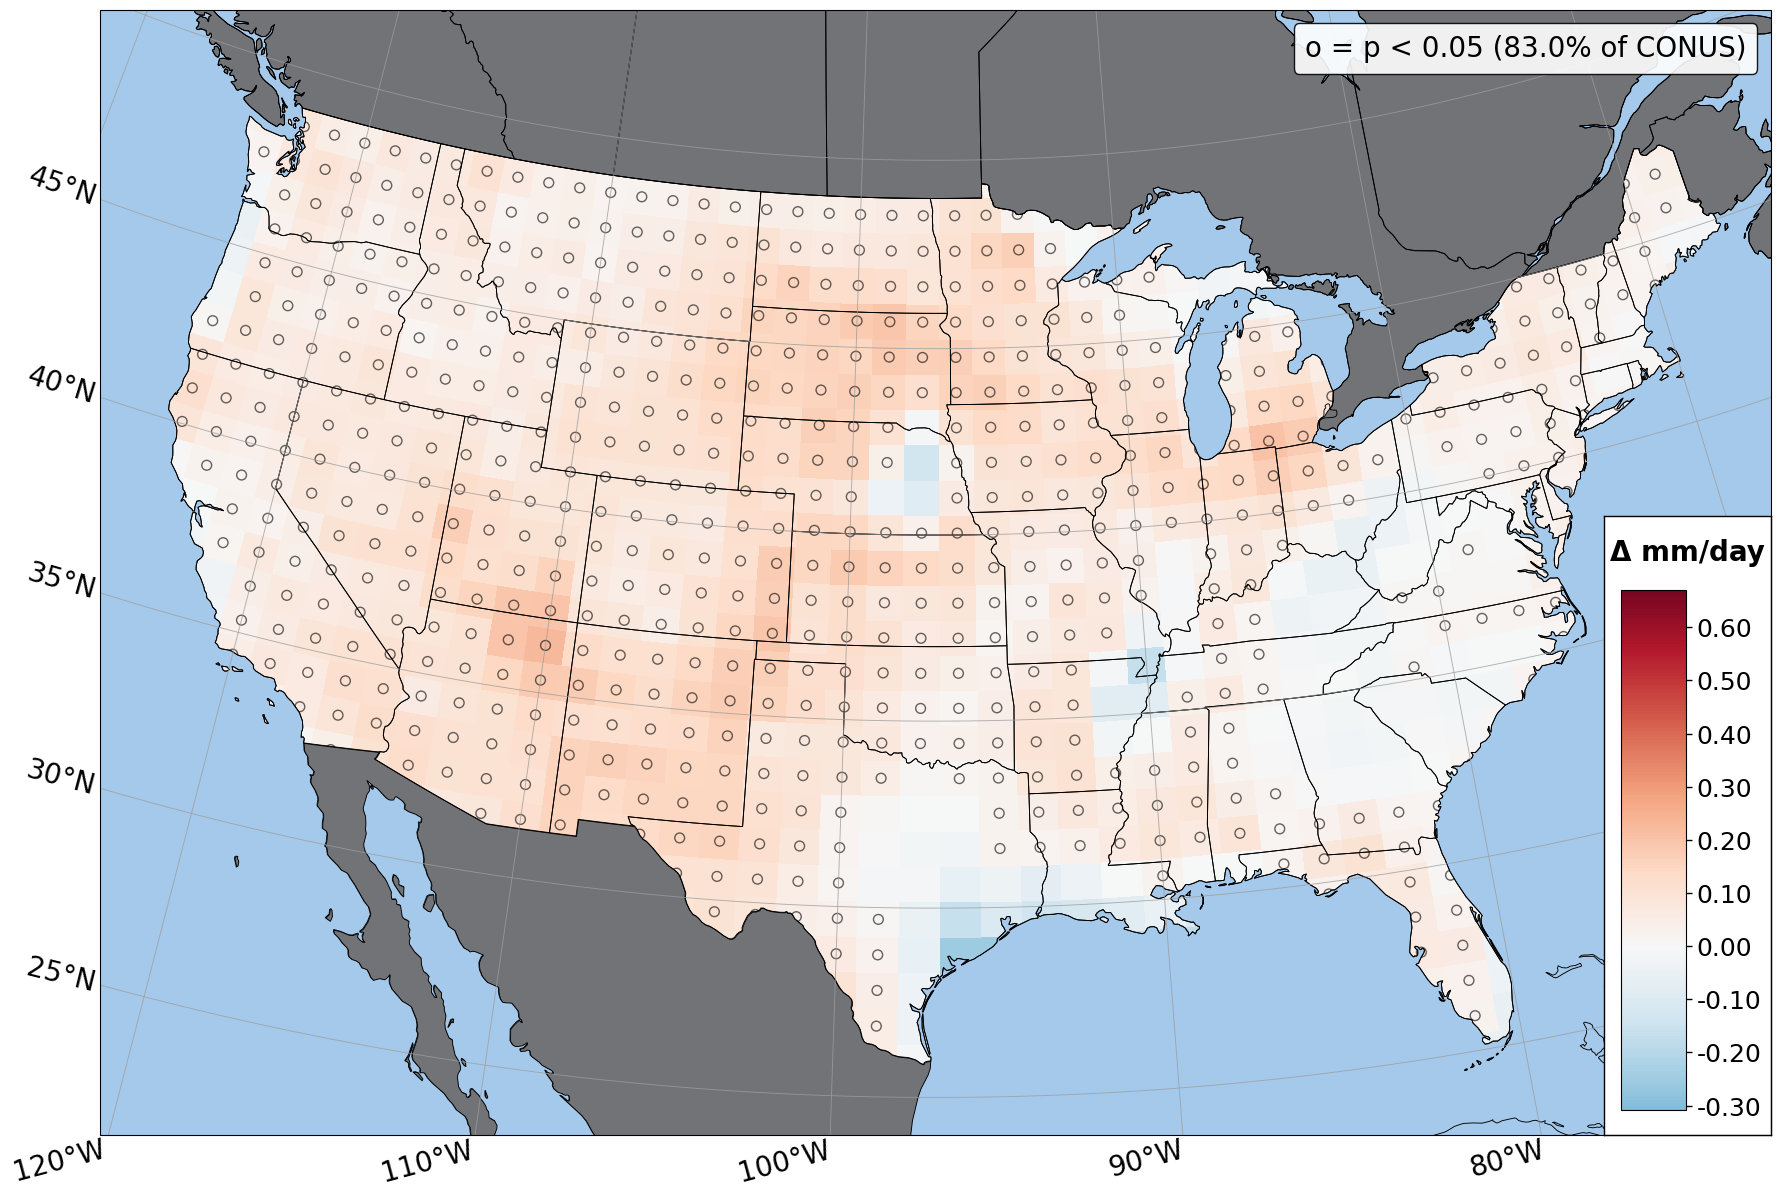

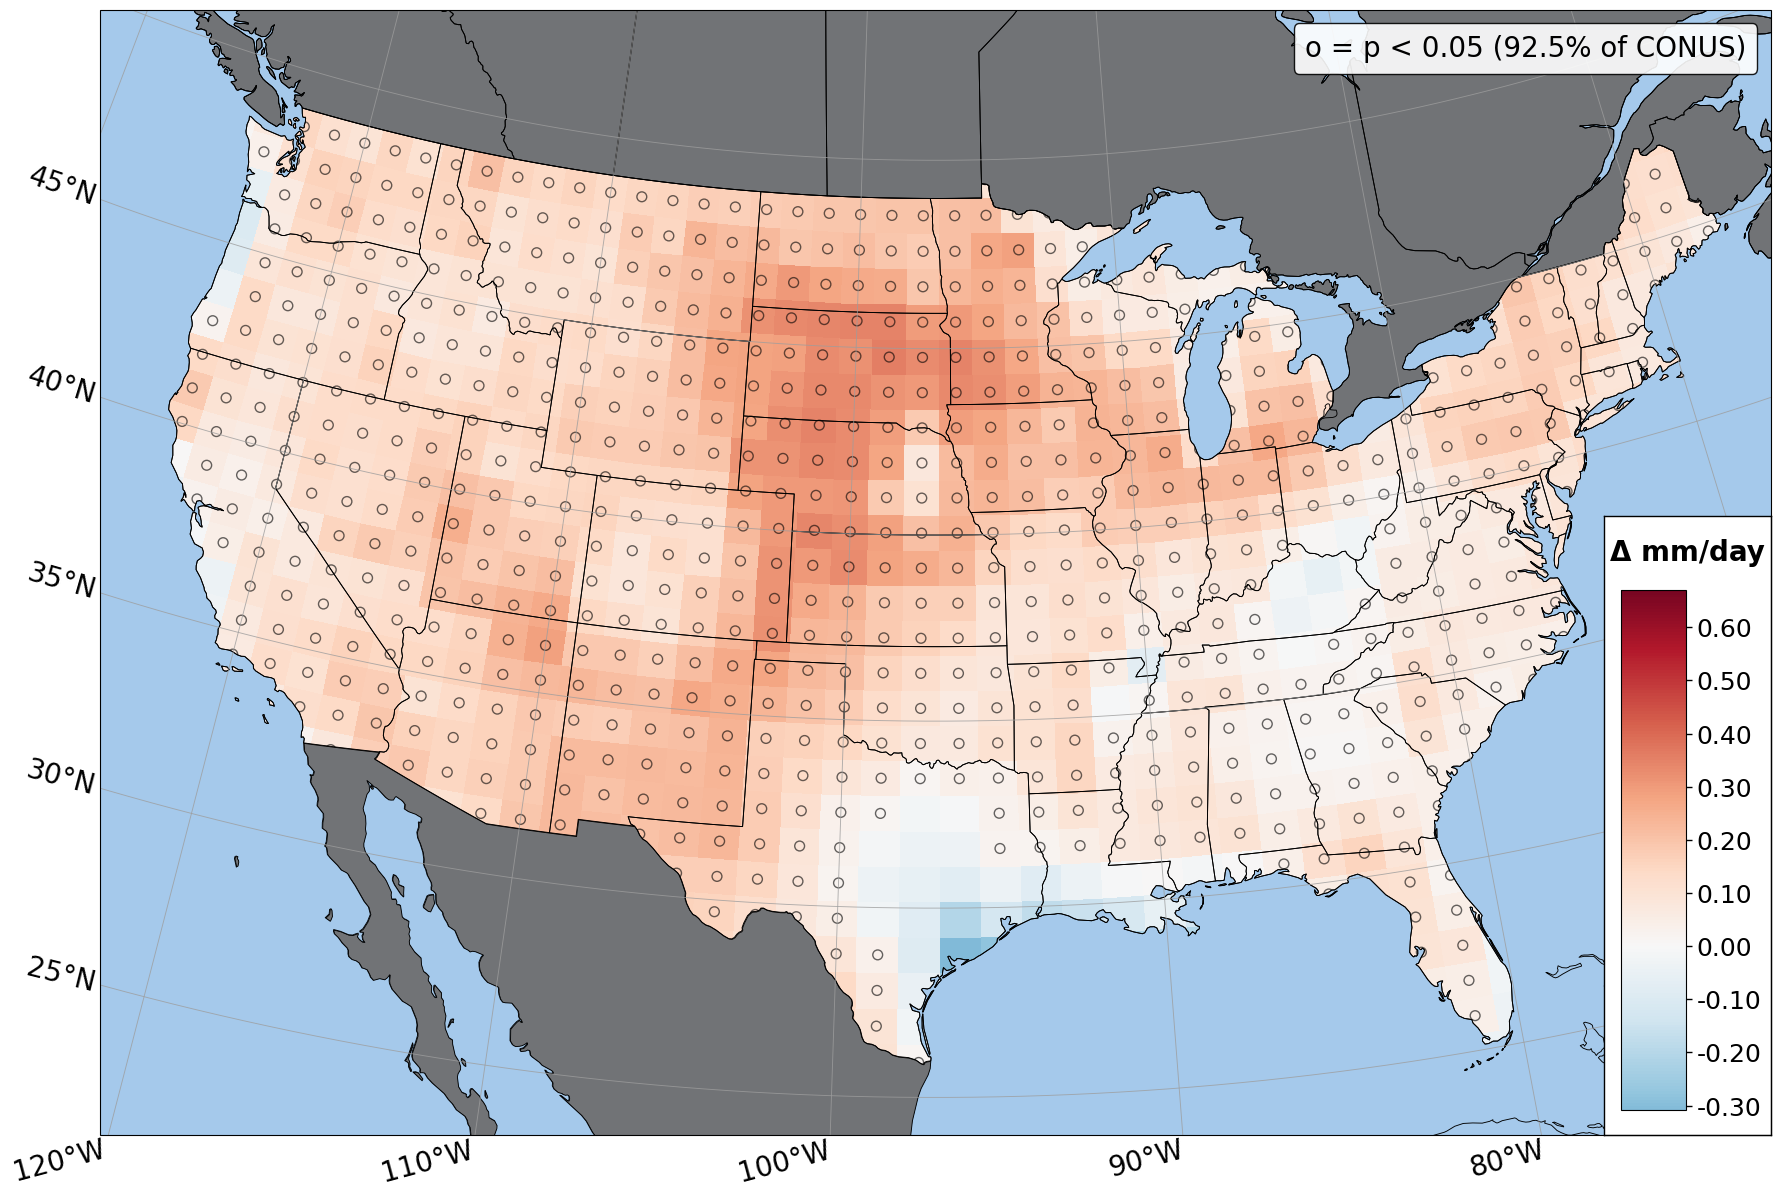

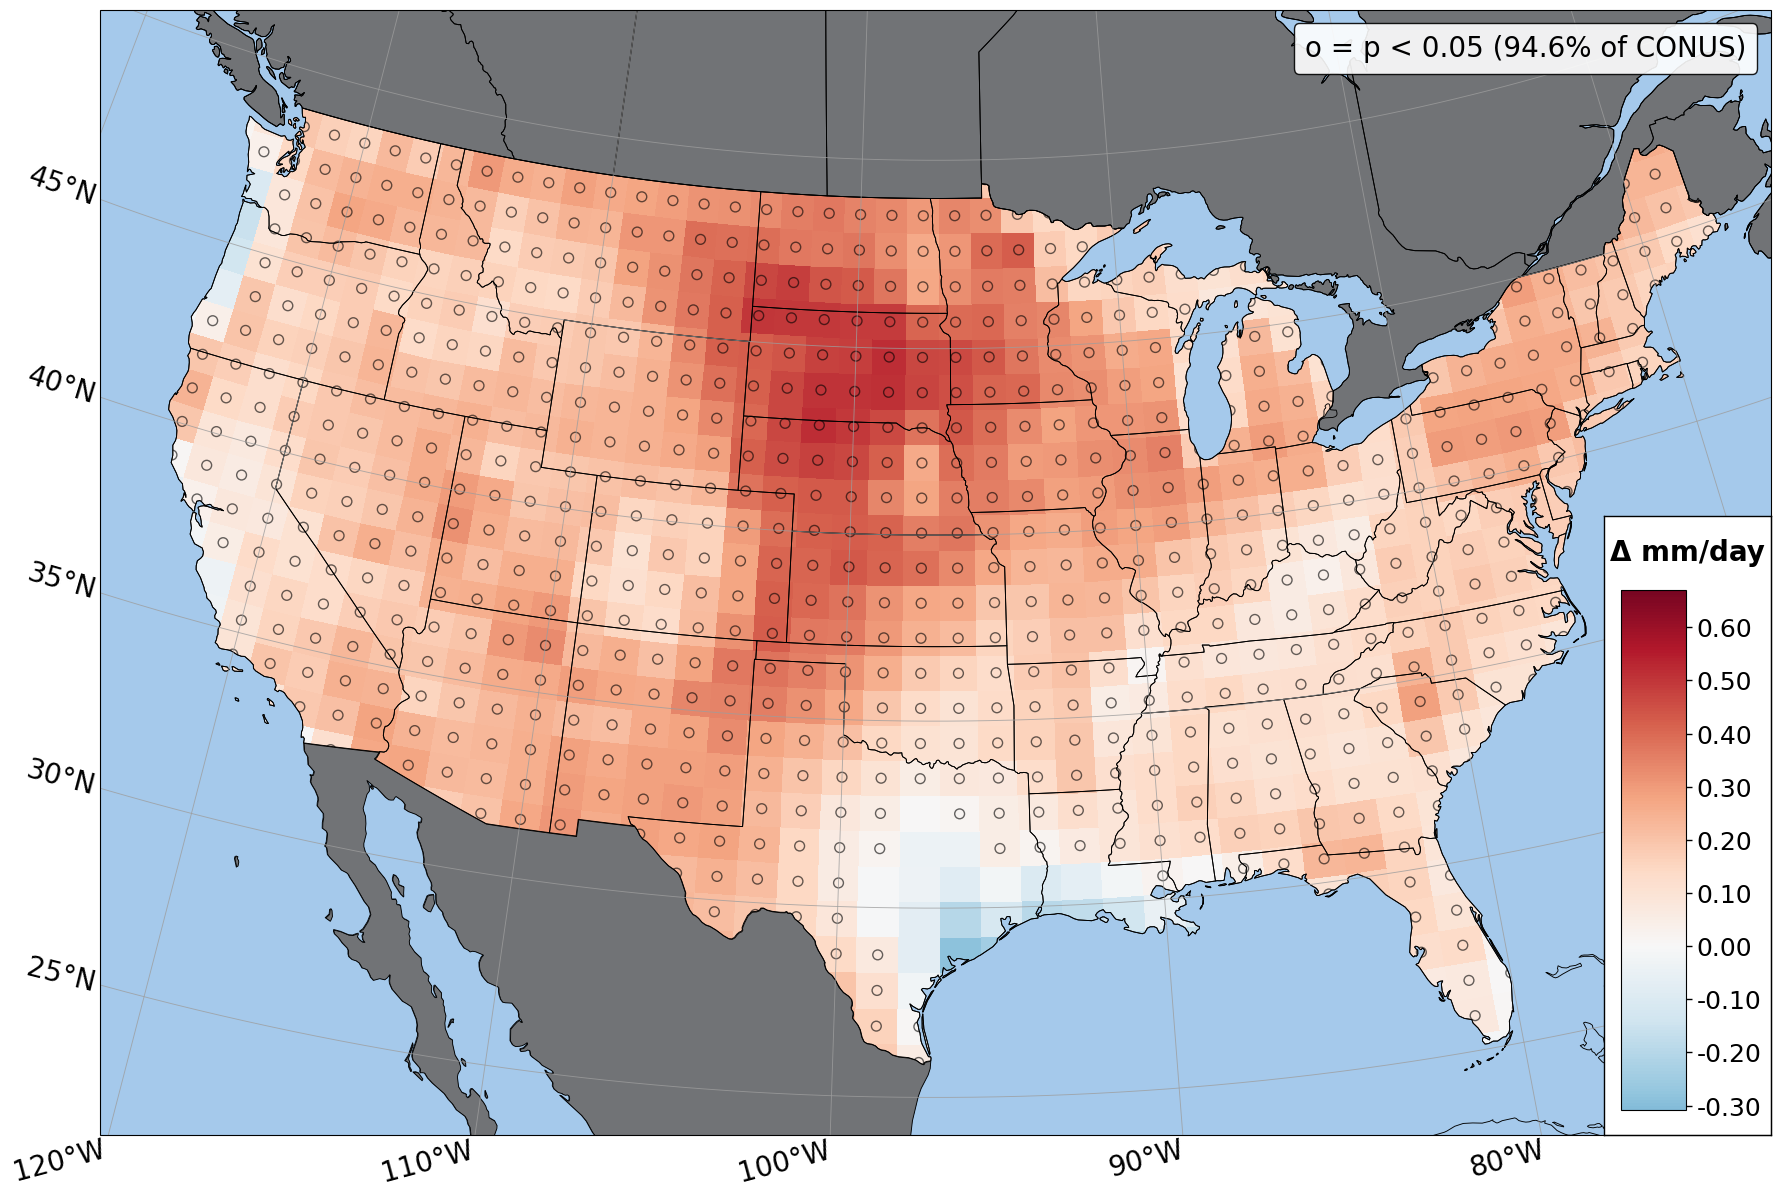

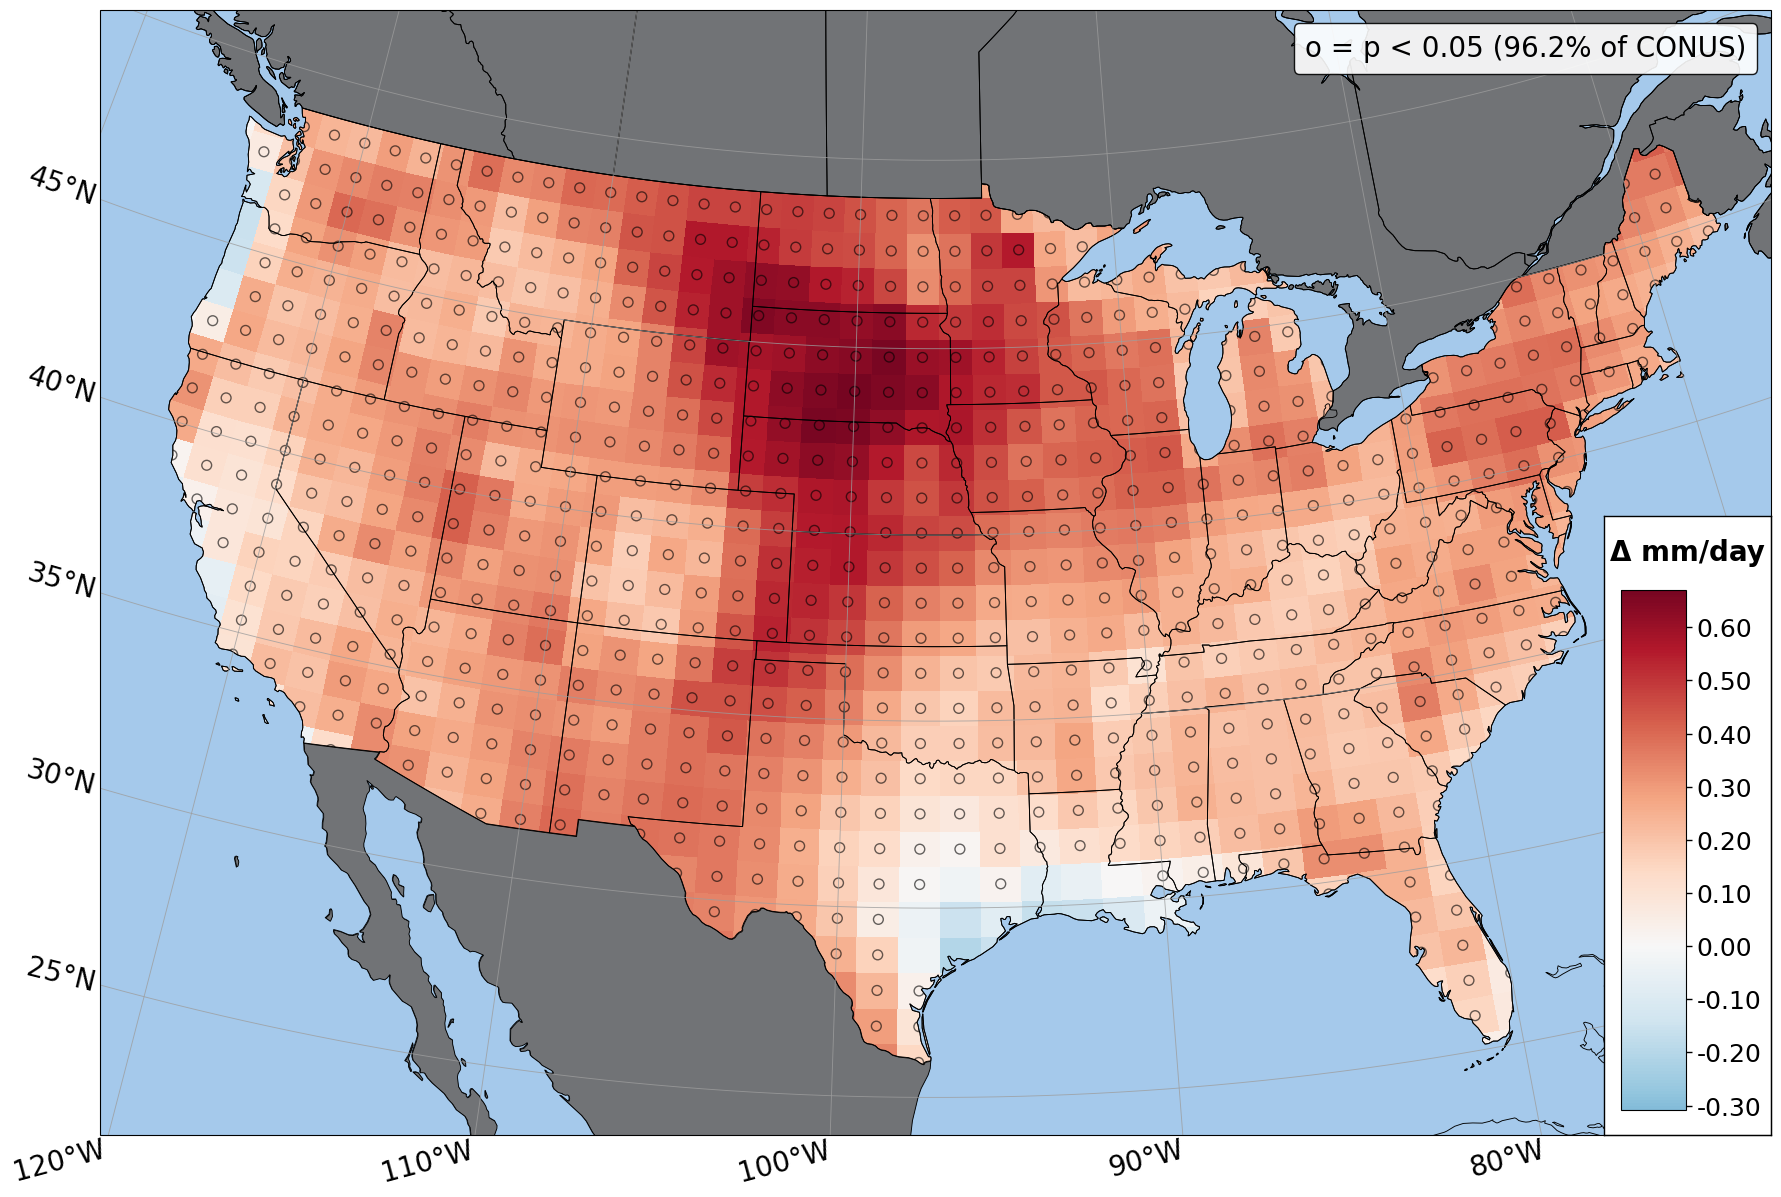

In [11]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import scipy.stats as stats
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.lines import Line2D

# -------------------------------------------------------------------------
# Helper Function 0: Custom Symmetric Tick & Range Generator
# -------------------------------------------------------------------------
def generate_custom_ticks_1(grid_values, step=0.1):
    """
    Computes exact data min/max within CONUS, symmetric limits for pcolormesh,
    and ticks spaced by 0.2, explicitly including the exact min value while
    excluding the maximum value from the tick marks.
    """
    exact_min = float(np.nanmin(grid_values))
    exact_max = float(np.nanmax(grid_values))
    
    if np.isnan(exact_min): 
        exact_min, exact_max = -1.0, 1.0
        
    # Symmetric limits rounded up to the nearest multiple of 'step'
    max_abs = np.ceil(max(abs(exact_min), abs(exact_max)) / step) * step
    if max_abs == 0:
        max_abs = step
        
    exact_min_sym = -max_abs
    exact_max_sym = max_abs
    
    # Generate potential ticks in increments of 0.2
    num_steps = int(np.round((exact_max_sym - exact_min_sym) / step)) + 1
    all_possible_ticks = np.round(np.linspace(exact_min_sym, exact_max_sym, num_steps), 2)
    
    # Filter ticks strictly within [exact_min, exact_max) - excluding exact_max
    custom_ticks = [t for t in all_possible_ticks if exact_min <= t < exact_max]
    
    # Explicitly include exact minimum and 0 if within bounds
    for required_val in [exact_min, 0.0]:
        if exact_min <= required_val < exact_max:
            if not any(np.isclose(required_val, t, atol=1e-4) for t in custom_ticks):
                custom_ticks.append(required_val)
                
    # Sort ticks and clean up float precision
    custom_ticks = sorted(list(np.round(custom_ticks, 2)))
    tick_labels = [f"{t:.2f}" for t in custom_ticks]
    
    return custom_ticks, tick_labels, exact_max_sym, exact_min_sym, exact_min, exact_max

# -------------------------------------------------------------------------
# Helper Function 1: Compute Delta, T-Test, and CONUS Masking
# -------------------------------------------------------------------------
def process_period_delta(df_earlier, df_later, mask_3d):
    """
    Computes delta (later - earlier) and Welch's t-test per grid cell,
    then masks results to CONUS.
    """
    earlier_dur_col = [c for c in ['mean_intensity', 'mean_annual_duration', 'duration'] if c in df_earlier.columns][0]
    later_dur_col = [c for c in ['mean_intensity', 'mean_annual_duration', 'duration'] if c in df_later.columns][0]

    merged = pd.merge(
        df_earlier[['lat', 'lon', 'member', earlier_dur_col]],
        df_later[['lat', 'lon', 'member', later_dur_col]],
        on=['lat', 'lon', 'member'],
        suffixes=('_earlier', '_later')
    )

    col_earlier = f"{earlier_dur_col}_earlier" if f"{earlier_dur_col}_earlier" in merged.columns else earlier_dur_col
    col_later = f"{later_dur_col}_later" if f"{later_dur_col}_later" in merged.columns else later_dur_col

    results = []
    for (lat, lon), group in merged.groupby(['lat', 'lon']):
        earlier_vals = group[col_earlier].values
        later_vals = group[col_later].values

        _, p_val = stats.ttest_ind(
            later_vals,
            earlier_vals,
            equal_var=False,  # Welch's t-test
            alternative='greater',
            nan_policy='omit'
        )

        delta_val = np.nanmean(later_vals) - np.nanmean(earlier_vals)
        results.append([lat, lon, p_val, delta_val])

    results_df = pd.DataFrame(results, columns=['lat', 'lon', 'p_value', 'delta'])

    delta_grid = results_df.pivot(index='lat', columns='lon', values='delta')
    p_val_grid = results_df.pivot(index='lat', columns='lon', values='p_value')

    delta_conus = delta_grid.where(mask_3d.values)
    p_val_conus = p_val_grid.where(mask_3d.values)

    return delta_conus, p_val_conus

# -------------------------------------------------------------------------
# Helper Function 2: Plotting Routine
# -------------------------------------------------------------------------
def plot_conus_delta_map(grid_delta, grid_pval, save_name, global_delta_values=None, alpha_sig=0.05):
    """
    Plots the delta grid as pcolormesh with explicit z-layering.
    Layering Hierarchy:
      zorder=1: Base Data Grid (pcolormesh)
      zorder=2: P-value scatter overlay
      zorder=3-4: Geometries, land/ocean features, coastlines, states
      zorder=5: Gridlines (above map features, beneath legend/colorbar UI)
      zorder=6: Legend box & Colorbar box
    """
    values_for_ticks = global_delta_values if global_delta_values is not None else grid_delta.values
    
    custom_ticks, tick_labels, exact_max_sym, exact_min_sym, exact_min, exact_max = generate_custom_ticks_1(values_for_ticks)

    X, Y = np.meshgrid(grid_delta.columns, grid_delta.index)

    # Calculate Significant Lat/Lon Mask and Spatial Percentage
    pval_flat = grid_pval.stack().reset_index(name='p_value')
    valid_conus_points = pval_flat['p_value'].dropna()
    
    sig_mask = pval_flat['p_value'] < alpha_sig
    sig_lons = pval_flat.loc[sig_mask, 'lon'].values
    sig_lats = pval_flat.loc[sig_mask, 'lat'].values

    if len(valid_conus_points) > 0:
        sig_pct = (sig_mask.sum() / len(valid_conus_points)) * 100
    else:
        sig_pct = 0.0

    s_lat, n_lat = 24, 52
    w_lon, e_lon = -121, -73

    crs = ccrs.LambertConformal(central_longitude=-97, central_latitude=40)

    fig = plt.figure(figsize=(18, 16))
    ax = plt.axes(projection=crs)
    ax.set_extent([w_lon, e_lon, s_lat, n_lat], crs=ccrs.PlateCarree())

    water_color = '#a5c9eb'
    ax.set_facecolor(water_color)

    # --- ZORDER 1: Base Data Grid ---
    im = ax.pcolormesh(
        X, Y, grid_delta.values,
        transform=ccrs.PlateCarree(),
        cmap='RdBu_r', 
        vmin=exact_min_sym, 
        vmax=exact_max_sym,
        shading='auto',
        zorder=1
    )

    # --- ZORDER 2: Scatter Layer for P-Values ---
    legend_label = f"o = p < {alpha_sig} ({sig_pct:.1f}% of CONUS)"
    if len(sig_lons) > 0:
        ax.scatter(
            sig_lons, sig_lats,
            transform=ccrs.PlateCarree(),
            s=50,
            marker='o', 
            facecolors='none', 
            edgecolors='black', 
            alpha=0.6,
            zorder=1
        )

    # --- ZORDER 3 & 4: Regional Geometries and Map Features ---
    if 'canada_geom' in globals() and canada_geom is not None:
        ax.add_geometries([canada_geom], crs=ccrs.PlateCarree(), facecolor='#717376', edgecolor='black', linewidth=0.65, zorder=1)
    if 'mexico_geom' in globals() and mexico_geom is not None:
        ax.add_geometries([mexico_geom], crs=ccrs.PlateCarree(), facecolor='#717376', edgecolor='black', linewidth=0.65, zorder=1)
    if 'great_lakes_geoms' in globals() and great_lakes_geoms:
        ax.add_geometries(great_lakes_geoms, crs=ccrs.PlateCarree(), facecolor=water_color, edgecolor='black', linewidth=0.65, zorder=1)

    ax.add_feature(cfeature.OCEAN.with_scale('50m'), facecolor=water_color, zorder=1)
    ax.coastlines('50m', linewidth=0.65, color='black', zorder=1)

    states = cfeature.NaturalEarthFeature(
        category='cultural', name='admin_1_states_provinces_lakes', scale='50m', facecolor='none'
    )
    ax.add_feature(states, edgecolor='black', linewidth=0.65, zorder=1)

    # --- ZORDER 5: Gridlines ---
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.65, color="#9d9d9d", zorder=1, alpha=0.8)
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = True
    gl.left_labels = True
    gl.x_inline = False
    gl.y_inline = False
    gl.xpadding = 4
    gl.ypadding = 4
    gl.xlabel_style = {'size': 20, 'color': 'black', 'rotation': 15}
    gl.ylabel_style = {'size': 20, 'color': 'black'}
    gl.xlocator = mticker.FixedLocator(range(-130, -60, 10))
    gl.ylocator = mticker.FixedLocator(range(20, 55, 5))

    # --- ZORDER 6: Top Level UI Overlay Boxes ---
    # 1. P-value Text Box Legend (Invisible handle removes extra marker symbol)
    if len(sig_lons) > 0:
        proxy_handle = Line2D(
            [0], [0],
            color='none',
            linestyle='none',
            marker='none',
            label=legend_label
        )

        leg = ax.legend(
            handles=[proxy_handle],
            loc='upper right', 
            frameon=True, 
            facecolor='white', 
            framealpha=0.9, 
            edgecolor='black',
            fontsize=20,
            handlelength=0,
            handletextpad=0
        )
        leg.set_zorder(2)

    # 2. Colorbar Inset Box Setup
    ax_box = ax.inset_axes([0.90, 0, 0.10, 0.55], zorder=2)
    ax_box.set_facecolor('white')
    ax_box.set_xticks([])
    ax_box.set_yticks([])
    for spine in ax_box.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor('black')
        spine.set_linewidth(1.0)

    cax = ax_box.inset_axes([0.10, 0.04, 0.39, 0.84])
    
    # Create Colorbar
    cb = plt.colorbar(im, cax=cax, orientation='vertical', ticks=custom_ticks)
    cb.ax.set_ylim(exact_min, exact_max)
    cb.ax.set_yticklabels(tick_labels, fontsize=18, color='black')
    cb.ax.tick_params(direction='out', length=4, width=1)

    ax_box.text(
        0.5, 0.94,
        "Δ mm/day",
        transform=ax_box.transAxes,
        fontsize=20,
        weight='bold', 
        color='black',
        ha='center',
        va='center'
    )

    plt.tight_layout()
    plt.savefig(f"{save_name}.png", dpi=300, bbox_inches='tight')
    plt.show()

# =========================================================================
# Execution Workflow Across Time Transitions
# =========================================================================

# 1. Build CONUS Spatial Mask
sample_lats = hist_member_means['lat'].unique()
sample_lons = hist_member_means['lon'].unique()
frac_mask_3d = us_states.mask_3D_frac_approx(sample_lons, sample_lats, wrap_lon=True)
any_overlap_mask = (frac_mask_3d > 0).any(dim="region")

# 2. Define Period Transitions relative to HIST Baseline
comparisons = [
    ("(2015–2036) - HIST", hist_member_means, ftr1_member_means_int, "int_Delta_Hist_to_Ftr1"),
    ("(2037–2058) - HIST", hist_member_means, ftr2_member_means_int, "int_Delta_Hist_to_Ftr2"),
    ("(2059–2079) - HIST", hist_member_means, ftr3_member_means_int, "int_Delta_Hist_to_Ftr3"),
    ("(2080–2100) - HIST", hist_member_means, ftr4_member_means_int, "int_Delta_Hist_to_Ftr4")
]

# 3. Compute Delta and Statistical Grids
processed_results = []
for title_suffix, df_base, df_comp, save_name in comparisons:
    delta_grid, pval_grid = process_period_delta(df_base, df_comp, any_overlap_mask)
    
    processed_results.append({
        'delta_grid': delta_grid,
        'pval_grid': pval_grid,
        'save_name': save_name
    })

# 4. Collect All CONUS Delta Values to Ensure Consistent Scaling Across Maps
all_delta_vals = np.concatenate([r['delta_grid'].values.flatten() for r in processed_results])

# 5. Render All Maps
for res in processed_results:
    plot_conus_delta_map(
        grid_delta=res['delta_grid'],
        grid_pval=res['pval_grid'],
        save_name=res['save_name'],
        global_delta_values=all_delta_vals,
        alpha_sig=0.05
    )